# **CYT180 — Project 1: Cleaning Real-World Firewall Logs**
**Student Name:** Aiswarya Shyam Sundar  
**Student ID:** 111172268  
**Course:** CYT180  



---
# **Part B — Section 1: Load & Profile the Dataset**

In [1]:
from google.colab import files
uploaded = files.upload()

Saving raw_firewall_logs.csv to raw_firewall_logs.csv


In [2]:
# Name: Aiswarya Shyamsundar
# Student ID: 111172268

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 25)

print('Libraries loaded.')

Libraries loaded.


**Load CSV**

In [3]:
df_raw = pd.read_csv('raw_firewall_logs.csv')
print('Loaded successfully.')

Loaded successfully.


**Shape and column names**

In [4]:
# Name: Aiswarya Shyamsundar
# Student ID: 111172268


print('=== SCREENSHOT 1 — Shape & Column Names ===')
print(f'Rows    : {df_raw.shape[0]}')
print(f'Columns : {df_raw.shape[1]}')
print()
print('Column names:')
for i, col in enumerate(df_raw.columns, 1):
    print(f'  {i:2d}. {col}')

=== SCREENSHOT 1 — Shape & Column Names ===
Rows    : 1010
Columns : 11

Column names:
   1. event_time
   2. src_ip
   3. dst_ip
   4. src_port
   5. dst_port
   6. protocol
   7. action
   8. bytes_in
   9. bytes_out
  10. country
  11. device


**Random sample of 10 rows (raw)**

In [5]:
# Name: Aiswarya Shyamsundar
# Student ID: 111172268

print('=== Raw Sample (before any cleaning) ===')
df_raw.sample(10, random_state=42)

=== Raw Sample (before any cleaning) ===


,event_time,src_ip,dst_ip,src_port,dst_port,protocol,action,bytes_in,bytes_out,country,device
629,22/01/2025 15:42,21.89.39.112,152.236.87.11,39823,4329,TCP,DENY,19135,43517,IT,FW-02
788,04/12/2025 21:14,154.204.134.79,192.168.191.85,9466,6695,TCP,DENIED,14358,36269,CH,CloudGW-2
684,12/09/2025 21:48,-131,172.22.61.46,41150,20673,Esp,DENY,7.0k,4.5k,SE,DC-FW
516,03/07/2025 01:00,59.137.98.84,175.233.180.252,50668,59655,Udp,allow,32001,17645,SE,HQ-FW
529,23/08/2025 01:23,248.126.6.40,172.22.172.235,60165,50248,GRE,DENY,1037,15091,ch,DC-FW
657,2025-02-21 16:19,149.204.58.178,49.227.80.210,24760,21143,UDP,ALLOW,24346,7826,es,FW-02
552,26/12/2025 00:43,101.1.243.176,243.7.205.10,22751,54584,Esp,DENY,39935,33617,in,DC-FW
531,21/02/2025 16:37,216.158.160.167,96.49.116.17,35790,44266,TCP,DENY,2270,18720,CA,FW-01
321,18/11/2025 21:05,246.89.145.137,87.245.251.15,38023,4784,ICMP,DENY,16509,23089,United States,CloudGW-2
70,20/02/2025 04:24,13.119.201.97,210.98.241.158,"44,440",3332,udp,DENY,984,33337,CN,FW-01


**Raw data types**

In [6]:
# Name: Aiswarya Shyamsundar
# Student ID: 111172268

print('Raw dtypes:')
print(df_raw.dtypes)

Raw dtypes:
event_time    object
src_ip        object
dst_ip        object
src_port      object
dst_port      object
protocol      object
action        object
bytes_in      object
bytes_out     object
country       object
device        object
dtype: object


**Missing value counts (profiling only — no changes)**

In [7]:
# Name: Aiswarya Shyamsundar
# Student ID: 111172268

print('=== SCREENSHOT 3 — Missing Value Counts ===')
print('(DataFrame NOT modified — profiling only)')
print()

missing = {}
for col in df_raw.columns:
    null_count  = df_raw[col].isna().sum()
    blank_count = df_raw[col].astype('str').str.strip().eq('').sum()
    missing[col] = null_count + blank_count

s = pd.Series(missing).sort_values(ascending=False)
df_miss = pd.DataFrame({
    'Missing/Blank': s,
    '% of Rows': (s / len(df_raw) * 100).round(2)
})
print(df_miss.to_string())

=== SCREENSHOT 3 — Missing Value Counts ===
(DataFrame NOT modified — profiling only)

            Missing/Blank  % of Rows
src_port               26       2.57
dst_port               25       2.48
country                16       1.58
event_time             12       1.19
bytes_in                6       0.59
bytes_out               6       0.59
src_ip                  0       0.00
dst_ip                  0       0.00
protocol                0       0.00
action                  0       0.00
device                  0       0.00


# **Section 2 — Identify Data Problems**

**Data quality issues table (11 issues)**

In [8]:
# Name: Aiswarya Shyamsundar
# Student ID: 111172268


print('=== Data Quality Issues ===')

issues = [
  [1, 'event_time',     'Two mixed timestamp formats',                 '"2025-06-28 1:39" vs "01/03/2025 13:53"',  'Cannot sort chronologically without a unified format'],
  [2, 'event_time',     'Blank/unparseable timestamps',                 'Empty string (12 rows)',                    'Missing timestamps break event timeline analysis'],
  [3, 'src_ip/dst_ip', 'Invalid IPv4 (out-of-range octets, dashes)',   '"281.279.-23.-11", "-114"',                  'Invalid IPs cannot be geolocated or matched to feeds'],
  [4, 'src_port',      'Comma-formatted port numbers loaded as string', '"44,440"',                                   'Prevents numeric filtering and range validation'],
  [5, 'dst_port',      'Out-of-range port values (> 65535)',           '"111556", "92257"',                          'Ports above 65535 are invalid in TCP/UDP'],
  [6, 'protocol',      'Casing drift across 15 variants',              '"tcp", "Tcp", "TCP", "Gre", "icmp"',         'GROUP BY fails to aggregate same protocol'],
  [7, 'action',        'Non-canonical variants + leading/trailing spaces', '" deny ", "DENIED", "ALLOWED", "Allow"',    'Accurate allow-vs-deny counts impossible'],
  [8, 'bytes_in/out',  'Commas, k-suffix units, and negative values',   '"10,165", "7.0k", "-10487"',                'Loads as object type; negatives are physically impossible'],
  [9, 'country',       'Mixed casing + full names mixed with ISO codes', '"it", "United States", "us", "US"',         'Same country appears under multiple keys'],
  [10, 'device',       'Leading and trailing whitespace',              '"  DC-FW  ", "  HQ-FW  "',                  'Device mismatches in joins and dashboards'],
  [11, 'all columns',  '~10 full-row duplicate records',               'Identical values across all 11 columns',    'Inflates alert counts and skews statistics'],
]

df_issues = pd.DataFrame(issues,
    columns=['#','Column(s)','Problem','Example Value','Why It Matters'])
pd.set_option('display.max_colwidth', 55)
display(df_issues)

=== Data Quality Issues ===


,#,Column(s),Problem,Example Value,Why It Matters
0,1,event_time,Two mixed timestamp formats,"""2025-06-28 1:39"" vs ""01/03/2025 13:53""",Cannot sort chronologically without a unified format
1,2,event_time,Blank/unparseable timestamps,Empty string (12 rows),Missing timestamps break event timeline analysis
2,3,src_ip/dst_ip,"Invalid IPv4 (out-of-range octets, dashes)","""281.279.-23.-11"", ""-114""",Invalid IPs cannot be geolocated or matched to feeds
3,4,src_port,Comma-formatted port numbers loaded as string,"""44,440""",Prevents numeric filtering and range validation
4,5,dst_port,Out-of-range port values (> 65535),"""111556"", ""92257""",Ports above 65535 are invalid in TCP/UDP
5,6,protocol,Casing drift across 15 variants,"""tcp"", ""Tcp"", ""TCP"", ""Gre"", ""icmp""",GROUP BY fails to aggregate same protocol
6,7,action,Non-canonical variants + leading/trailing spaces,""" deny "", ""DENIED"", ""ALLOWED"", ""Allow""",Accurate allow-vs-deny counts impossible
7,8,bytes_in/out,"Commas, k-suffix units, and negative values","""10,165"", ""7.0k"", ""-10487""",Loads as object type; negatives are physically impo...
8,9,country,Mixed casing + full names mixed with ISO codes,"""it"", ""United States"", ""us"", ""US""",Same country appears under multiple keys
9,10,device,Leading and trailing whitespace,""" DC-FW "", "" HQ-FW """,Device mismatches in joins and dashboards


# **Section 3 — Clean & Standardize**

**Create working copy**

In [9]:
df = df_raw.copy()
print(f'Working copy created. Shape: {df.shape}')

Working copy created. Shape: (1010, 11)


**3.1 — Clean event_time (parse both formats → UTC)**

In [10]:
# Name: Aiswarya Shyamsundar
# Student ID: 111172268


print('=== event_time ===')
print('Assumption: raw timestamps are naive; localized to UTC.')
print()

def parse_event_time(val):
    if pd.isna(val) or str(val).strip() == '':
        return pd.NaT
    val = str(val).strip()
    for fmt in ['%Y-%m-%d %H:%M', '%Y-%m-%d %I:%M']:
        try: return pd.to_datetime(val, format=fmt).tz_localize('UTC')
        except: pass
    try: return pd.to_datetime(val, format='%d/%m/%Y %H:%M').tz_localize('UTC')
    except: pass
    return pd.NaT

print('Before — sample raw values:')
print(df['event_time'].head(4).tolist())
print()
df['event_time'] = df['event_time'].apply(parse_event_time)
print(f'Parsed OK : {df["event_time"].notna().sum()}')
print(f'Set to NaT: {df["event_time"].isna().sum()} (blank or unparseable)')
print(f'dtype     : {df["event_time"].dtype}')
print()
print('After — sample cleaned:')
print(df['event_time'].dropna().head(4).to_string())

=== event_time ===
Assumption: raw timestamps are naive; localized to UTC.

Before — sample raw values:
['2025-08-11 14:53', '2025-06-28 1:39', '01/03/2025 13:53', '2025-06-07 8:44']

Parsed OK : 998
Set to NaT: 12 (blank or unparseable)
dtype     : datetime64[ns, UTC]

After — sample cleaned:
0   2025-08-11 14:53:00+00:00
1   2025-06-28 01:39:00+00:00
2   2025-03-01 13:53:00+00:00
3   2025-06-07 08:44:00+00:00


**3.2 — Clean src_ip / dst_ip (validate IPv4)**

In [12]:
# Name: Aiswarya Shyamsundar
# Student ID: 111172268


print('=== src_ip / dst_ip ===')

def validate_ipv4(val):
    val = str(val).strip()
    parts = val.split('.')
    if len(parts) != 4: return np.nan
    try:
        return val if all(0 <= int(p) <= 255 for p in parts) else np.nan
    except: return np.nan

for col in ['src_ip', 'dst_ip']:
    inv = df[col].apply(lambda x: pd.isna(validate_ipv4(x))).sum()
    print(f'{col} — invalid values found : {inv}')
    df[col] = df[col].apply(validate_ipv4)
    print(f'{col} — NaN after cleaning   : {df[col].isna().sum()}')
    print()

=== src_ip / dst_ip ===
src_ip — invalid values found : 102
src_ip — NaN after cleaning   : 102

dst_ip — invalid values found : 40
dst_ip — NaN after cleaning   : 40



**3.3 — Clean src_port / dst_port (commas, range)**

In [13]:
# Name: Aiswarya Shyamsundar
# Student ID: 111172268

print('=== src_port / dst_port ===')

def clean_port(val):
    val = str(val).strip().replace(',', '')
    try:
        p = int(float(val))
        return p if 0 <= p <= 65535 else np.nan
    except: return np.nan

for col in ['src_port', 'dst_port']:
    nan_before = df[col].isna().sum()
    df[col] = df[col].apply(clean_port)
    valid = df[col].dropna()
    print(f'{col}: NaN before={nan_before} | NaN after={df[col].isna().sum()}')
    print(f'{col}: min={int(valid.min())} | max={int(valid.max())} | all in 0-65535: {valid.between(0,65535).all()}')
    print()

=== src_port / dst_port ===
src_port: NaN before=22 | NaN after=26
src_port: min=26 | max=65512 | all in 0-65535: True

dst_port: NaN before=25 | NaN after=35
dst_port: min=183 | max=65488 | all in 0-65535: True



**3.4 — Clean protocol (uppercase, valid set only)**

In [15]:
# Name: Aiswarya Shyamsundar
# Student ID: 111172268

print('=== protocol ===')
valid_proto = {'TCP', 'UDP', 'ICMP', 'GRE', 'ESP'}

print('BEFORE:')
print(df['protocol'].value_counts(dropna=False).to_string())
print()

df['protocol'] = df['protocol'].astype('str').str.strip().str.upper()
df.loc[~df['protocol'].isin(valid_proto), 'protocol'] = np.nan

print('AFTER:')
print(df['protocol'].value_counts(dropna=False).to_string())

=== protocol ===
BEFORE:
protocol
TCP     206
GRE     206
UDP     201
ICMP    199
ESP     198

AFTER:
protocol
TCP     206
GRE     206
UDP     201
ICMP    199
ESP     198


**3.5 — Clean action (normalize + uppercase)**

In [16]:
# Name: Aiswarya Shyamsundar
# Student ID: 111172268

print('=== action ===')
valid_actions = {'ALLOW', 'DENY'}

print('BEFORE:')
print(df['action'].value_counts(dropna=False).to_string())
print()

df['action'] = df['action'].astype('str').str.strip().str.upper()
df['action'] = df['action'].replace({'ALLOWED': 'ALLOW', 'DENIED': 'DENY'})
df.loc[~df['action'].isin(valid_actions), 'action'] = np.nan

print('AFTER:')
print(df['action'].value_counts(dropna=False).to_string())

=== action ===
BEFORE:
action
DENY       352
ALLOW      318
Allow       66
 deny       62
 allow      59
DENIED      52
ALLOWED     52
Deny        49

AFTER:
action
DENY     515
ALLOW    495


**3.6 — Clean bytes_in / bytes_out (commas, k-units, negatives)**

In [17]:
# Name: Aiswarya Shyamsundar
# Student ID: 111172268

print('=== bytes_in / bytes_out ===')
print('Assumptions: k-suffix = x1000 | negatives clamped to 0')
print()

def clean_bytes(val):
    val = str(val).strip().replace(',', '')
    if val == '' or val.lower() == 'nan': return np.nan
    if val.lower().endswith('k'):
        try: return max(0.0, float(val[:-1]) * 1000)
        except: return np.nan
    try: return max(0.0, float(val))
    except: return np.nan

for col in ['bytes_in', 'bytes_out']:
    neg = df[col].astype('str').str.match(r'^-\d').sum()
    k   = df[col].astype('str').str.lower().str.endswith('k').sum()
    df[col] = df[col].apply(clean_bytes)
    print(f'{col}: negatives clamped={neg} | k-values converted={k}')
    print(f'{col}: min={df[col].min()} | max={df[col].max()} | NaN={df[col].isna().sum()}')
    print()

=== bytes_in / bytes_out ===
Assumptions: k-suffix = x1000 | negatives clamped to 0

bytes_in: negatives clamped=5 | k-values converted=30
bytes_in: min=0.0 | max=49939.0 | NaN=6

bytes_out: negatives clamped=3 | k-values converted=30
bytes_out: min=0.0 | max=49987.0 | NaN=6



**3.7 — Clean country (uppercase, blanks → NaN)**

In [18]:
# Name: Aiswarya Shyamsundar
# Student ID: 111172268

print('=== country ===')
print('BEFORE (top 8):')
print(df['country'].value_counts(dropna=False).head(8).to_string())
print()

df['country'] = df['country'].astype('str').str.strip().str.upper()
df.loc[df['country'].isin(['', 'NAN']), 'country'] = np.nan

print('AFTER (top 8):')
print(df['country'].value_counts(dropna=False).head(8).to_string())
print(f'\nNaN count: {df["country"].isna().sum()}')

=== country ===
BEFORE (top 8):
country
Canada           57
DE               55
CN               53
CA               53
United States    53
BR               50
CH               48
ES               44

AFTER (top 8):
country
DE        67
BR        63
CN        63
CA        63
ES        62
CANADA    57
CH        57
IT        56

NaN count: 16


**3.8 — Clean device (strip whitespace)**

In [19]:
# Name: Aiswarya Shyamsundar
# Student ID: 111172268

print('=== device ===')

has_spaces = df['device'].astype('str').str.startswith(' ') | df['device'].astype('str').str.endswith(' ')
print(f'Values with leading/trailing spaces before: {has_spaces.sum()}')
print('Examples:', df.loc[has_spaces, 'device'].unique()[:3].tolist())
print()

df['device'] = df['device'].astype('str').str.strip()

print(f'Values with spaces after: {(df["device"].str.startswith(" ") | df["device"].str.endswith(" ")).sum()}')
print()
print('Unique device names:')
print(df['device'].value_counts().to_string())

=== device ===
Values with leading/trailing spaces before: 15
Examples: ['  DC-FW  ', '  FW-02  ', '  HQ-FW  ']

Values with spaces after: 0

Unique device names:
device
DC-FW        171
FW-02        154
BR-FW-1      148
HQ-FW        145
CloudGW-2    138
CloudGW-1    136
FW-01        118


**3.9 — Remove duplicate rows**

In [20]:
# Name: Aiswarya Shyamsundar
# Student ID: 111172268

print('=== Duplicates ===')

rows_before = len(df)
dupes       = df.duplicated().sum()
print(f'Rows before          : {rows_before}')
print(f'Full-row dupes found : {dupes}')

df = df.drop_duplicates().reset_index(drop=True)

print(f'Rows after           : {len(df)}')
print(f'Rows removed         : {rows_before - len(df)}')
print(f'Remaining dupes      : {df.duplicated().sum()}')

=== Duplicates ===
Rows before          : 1010
Full-row dupes found : 10
Rows after           : 1000
Rows removed         : 10
Remaining dupes      : 0


**Section 3.10 — Validation Checks**

In [21]:
# Name: Aiswarya Shyamsundar
# Student ID: 111172268

print('=== Validation 1: Port Range ===')
for col in ['src_port', 'dst_port']:
    v = df[col].dropna()
    oor = v[(v < 0) | (v > 65535)]
    status = 'PASS ✓' if len(oor) == 0 else f'FAIL — {len(oor)} out-of-range'
    print(f'{col}: min={int(v.min())} | max={int(v.max())} | out-of-range={len(oor)} → {status}')

=== Validation 1: Port Range ===
src_port: min=26 | max=65512 | out-of-range=0 → PASS ✓
dst_port: min=183 | max=65488 | out-of-range=0 → PASS ✓


**Validation 2 — Protocol and action valid categories**

In [22]:
# Name: Aiswarya Shyamsundar
# Student ID: 111172268

print('=== Validation 2: Categories ===')

proto_u  = set(df['protocol'].dropna().unique())
action_u = set(df['action'].dropna().unique())

print(f'protocol unique: {sorted(proto_u)}')
print(f'All in valid set: {proto_u <= {"TCP","UDP","ICMP","GRE","ESP"}} → {"PASS ✓" if proto_u <= {"TCP","UDP","ICMP","GRE","ESP"} else "FAIL ✗"}')
print()
print(f'action unique: {sorted(action_u)}')
print(f'All in valid set: {action_u <= {"ALLOW","DENY"}} → {"PASS ✓" if action_u <= {"ALLOW","DENY"} else "FAIL ✗"}')

=== Validation 2: Categories ===
protocol unique: ['ESP', 'GRE', 'ICMP', 'TCP', 'UDP']
All in valid set: True → PASS ✓

action unique: ['ALLOW', 'DENY']
All in valid set: True → PASS ✓


**Validation 3 — No negative byte values**

In [23]:
# Name: Aiswarya Shyamsundar
# Student ID: 111172268

print('=== Validation 3: No Negative Bytes ===')
for col in ['bytes_in', 'bytes_out']:
    v = df[col].dropna()
    neg = (v < 0).sum()
    status = 'PASS ✓' if neg == 0 else f'FAIL — {neg} negatives'
    print(f'{col}: min={v.min()} | negatives={neg} → {status}')

=== Validation 3: No Negative Bytes ===
bytes_in: min=0.0 | negatives=0 → PASS ✓
bytes_out: min=0.0 | negatives=0 → PASS ✓


**Validation 4 — No duplicate rows remain**

In [24]:
# Name: Aiswarya Shyamsundar
# Student ID: 111172268

print('=== Validation 4: No Duplicates ===')
rem = df.duplicated().sum()
status = 'PASS ✓' if rem == 0 else f'FAIL — {rem} remain'
print(f'Raw rows     : {len(df_raw)}')
print(f'Cleaned rows : {len(df)}')
print(f'Removed      : {len(df_raw) - len(df)}')
print(f'Remaining    : {rem} → {status}')

=== Validation 4: No Duplicates ===
Raw rows     : 1010
Cleaned rows : 1000
Removed      : 10
Remaining    : 0 → PASS ✓


**Validation 5 — All remaining IPs are valid IPv4**

In [25]:
# Name: Aiswarya Shyamsundar
# Student ID: 111172268

print('=== Validation 5: IPs Valid ===')

def is_valid_ipv4(val):
    if pd.isna(val): return True
    parts = str(val).split('.')
    if len(parts) != 4: return False
    try: return all(0 <= int(p) <= 255 for p in parts)
    except: return False

for col in ['src_ip', 'dst_ip']:
    inv = (~df[col].apply(is_valid_ipv4)).sum()
    status = 'PASS ✓' if inv == 0 else f'FAIL — {inv} invalid'
    print(f'{col}: valid={df[col].notna().sum()} | NaN={df[col].isna().sum()} | invalid remaining={inv} → {status}')

=== Validation 5: IPs Valid ===
src_ip: valid=900 | NaN=100 | invalid remaining=0 → PASS ✓
dst_ip: valid=960 | NaN=40 | invalid remaining=0 → PASS ✓


**Section 3.11 — Visualization**

**ALLOW vs DENY bar chart (cleaned data)**

=== Visualization ===


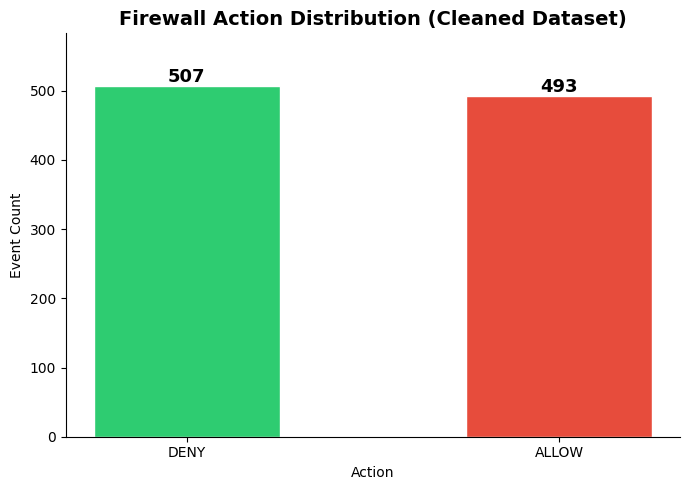

ALLOW: 493 | DENY: 507

Description: DENY (507) slightly outnumbers ALLOW (493), showing the
firewall is actively blocking ~half of all traffic — a healthy posture.


In [26]:
# Name: Aiswarya Shyamsundar
# Student ID: 111172268

print('=== Visualization ===')
counts = df['action'].value_counts(dropna=True)
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(counts.index, counts.values,
             color=['#2ecc71', '#e74c3c'], width=0.5, edgecolor='white')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(val), ha='center', fontsize=13, fontweight='bold')
ax.set_title('Firewall Action Distribution (Cleaned Dataset)', fontsize=14, fontweight='bold')
ax.set_xlabel('Action'); ax.set_ylabel('Event Count')
ax.set_ylim(0, counts.max() * 1.15)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()
print(f'ALLOW: {counts.get("ALLOW",0)} | DENY: {counts.get("DENY",0)}')
print()
print('Description: DENY (507) slightly outnumbers ALLOW (493), showing the')
print('firewall is actively blocking ~half of all traffic — a healthy posture.')

**Final cleaned dataset preview**

In [27]:
# Name: Aiswarya Shyamsundar
# Student ID: 111172268

print(f'Final shape: {df.shape}')
df.sample(10, random_state=1)

Final shape: (1000, 11)


,event_time,src_ip,dst_ip,src_port,dst_port,protocol,action,bytes_in,bytes_out,country,device
507,2025-03-28 10:40:00+00:00,NaN,20.151.163.34,40758.0,14255.0,UDP,DENY,24873.0,19374.0,CANADA,HQ-FW
818,2025-04-18 16:54:00+00:00,10.234.207.110,252.67.138.205,50155.0,18675.0,TCP,DENY,39138.0,32299.0,CH,FW-01
452,2025-10-27 03:51:00+00:00,127.139.72.2,243.184.12.47,64138.0,11952.0,GRE,ALLOW,44083.0,28243.0,RU,BR-FW-1
368,2025-10-16 00:10:00+00:00,98.155.1.94,172.28.159.208,1938.0,NaN,ICMP,DENY,24459.0,2661.0,BR,HQ-FW
242,2025-09-10 21:16:00+00:00,213.183.182.112,226.216.94.113,39501.0,8131.0,ICMP,ALLOW,45841.0,49987.0,IN,CloudGW-2
929,2025-10-23 20:06:00+00:00,170.175.139.96,10.109.29.122,5285.0,48826.0,ICMP,DENY,46581.0,20872.0,SE,CloudGW-2
262,2025-07-04 09:30:00+00:00,90.243.85.159,10.23.38.124,39624.0,20584.0,ESP,DENY,28794.0,19541.0,ES,CloudGW-2
810,2025-04-24 05:57:00+00:00,136.86.15.77,165.223.138.20,13686.0,3087.0,ESP,DENY,40888.0,36543.0,US,HQ-FW
318,2025-04-16 18:14:00+00:00,56.134.117.217,10.5.193.149,51222.0,8512.0,ICMP,ALLOW,19845.0,7405.0,CN,HQ-FW
49,2025-11-08 10:08:00+00:00,70.84.56.126,57.107.214.254,58841.0,26437.0,TCP,DENY,6654.0,47923.0,SE,BR-FW-1
